### Exploratory Data Analysis (EDA)
The goal of this notebook is to 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

df_cleaned=preprocess_data(file_path)
df_cleaned.to_csv(output_path, index=False)


Dropping columns with > 50% missing values: smoking, tjc_28, sjc_28, vas


Variables with more than 50% missing values were identified and excluded from further analysis prior to modeling. The table below shows these variables and their percentage of missingness.
Tjc28, and scj28 are excluded also because they are highly correlated to DAS28, that has less missingness.

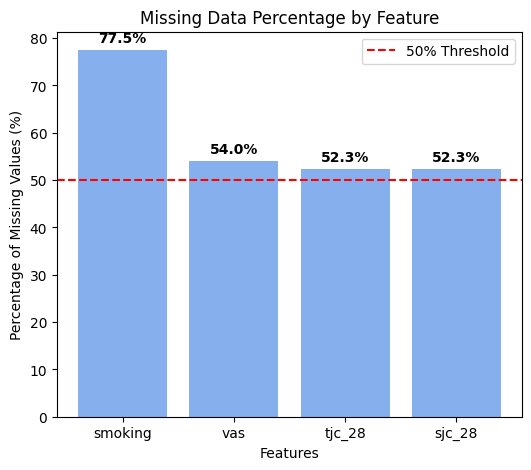

In [186]:
from src.preprocessing import handle_categorical_missing, load_data

df_raw = load_data(file_path)
handle_categorical_missing(df_raw)

missing_percent = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
high_missing = missing_percent[missing_percent > 50]

plt.figure(figsize=(6, 5))
graph = plt.bar(high_missing.index.to_numpy(), high_missing.to_numpy(), color="#85b0ed")

for p in graph:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    plt.text(
        x,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        weight="bold"
    )
plt.axhline(50, color='red', linestyle='--', label='50% Threshold')
plt.title('Missing Data Percentage by Feature')
plt.xlabel('Features')
plt.ylabel('Percentage of Missing Values (%)')
plt.legend()
plt.show()

#### Dataset Overview

In [187]:
df_cleaned.shape

(228, 46)

In [188]:
df_cleaned.head(10)

,patient_id,gender,year_of_diagnosis,rf_status,anti_ccp_status,comorbidities,visit_date,visit_type,crp,crp_upper_limit,...,comorb_gastrointestinal_hepatic,comorb_malignancy,comorb_musculoskeletal,comorb_neurologic_psychiatric,comorb_autoimmune_other,comorbidity_count,csdmard_use,b_ts_dmard_use,steroid_use,treatment_count
0,RA001,1,1997,0,0,"depression,hypothyroidism",2017-12-18,Baseline,0.40,0.5,...,0,0,0,1,0,2,1,1,0,3
1,RA001,1,1997,0,0,"depression,hypothyroidism",2018-03-20,Follow-up,NaN,NaN,...,0,0,0,1,0,2,1,0,0,2
2,RA001,1,1997,0,0,"depression,hypothyroidism",2018-09-25,Follow-up,0.40,0.5,...,0,0,0,1,0,2,0,1,0,1
4,RA002,1,1999,0,0,,2023-10-27,Baseline,0.02,0.5,...,0,0,0,0,0,0,1,1,0,3
5,RA002,1,1999,0,0,,2024-01-30,Follow-up,0.07,0.5,...,0,0,0,0,0,0,1,1,0,2
6,RA002,1,1999,0,0,,2024-04-23,Follow-up,1.90,5.0,...,0,0,0,0,0,0,1,1,0,2
7,RA002,1,1999,0,0,,2024-09-17,Follow-up,0.10,0.5,...,0,0,0,0,0,0,1,1,0,2
9,RA003,0,2005,1,1,transient ischemic attack,2023-09-01,Baseline,0.46,0.5,...,0,0,0,0,0,1,0,0,0,0
11,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-05-16,Baseline,NaN,NaN,...,0,0,0,0,0,1,1,0,1,3
12,RA004,0,2016,1,1,chronic obstructive pulmonary disease,2016-09-20,Follow-up,6.60,5.0,...,0,0,0,0,0,1,1,0,1,2


In [189]:
df_cleaned.columns.to_list()

['patient_id',
 'gender',
 'year_of_diagnosis',
 'rf_status',
 'anti_ccp_status',
 'comorbidities',
 'visit_date',
 'visit_type',
 'crp',
 'crp_upper_limit',
 'esr',
 'das28_score',
 'csdmard_name',
 'mtx_use',
 'mtx_dose',
 'b_ts_dmard_name',
 'steroid_dose',
 'treatment_decision',
 'switch_reason',
 'flare_event',
 'source',
 'birth_year',
 'days_since_last_visit',
 'disease_duration',
 'age_at_visit',
 'das28_change',
 'previous_flare',
 'target_flare_next',
 'crp_missing',
 'esr_missing',
 'crp_normalized',
 'inflammation_flag',
 'comorb_cardiovascular',
 'comorb_metabolic_endocrine',
 'comorb_respiratory',
 'comorb_renal_urological',
 'comorb_gastrointestinal_hepatic',
 'comorb_malignancy',
 'comorb_musculoskeletal',
 'comorb_neurologic_psychiatric',
 'comorb_autoimmune_other',
 'comorbidity_count',
 'csdmard_use',
 'b_ts_dmard_use',
 'steroid_use',
 'treatment_count']

In [190]:
cols_to_drop = ['year_of_diagnosis', 'crp', 'crp_upper_limit', 'source']
df_eda = df_cleaned.drop(columns=cols_to_drop)
df_eda.head()

,patient_id,gender,rf_status,anti_ccp_status,comorbidities,visit_date,visit_type,esr,das28_score,csdmard_name,...,comorb_gastrointestinal_hepatic,comorb_malignancy,comorb_musculoskeletal,comorb_neurologic_psychiatric,comorb_autoimmune_other,comorbidity_count,csdmard_use,b_ts_dmard_use,steroid_use,treatment_count
0,RA001,1,0,0,"depression,hypothyroidism",2017-12-18,Baseline,24.0,4.07,Azathioprine,...,0,0,0,1,0,2,1,1,0,3
1,RA001,1,0,0,"depression,hypothyroidism",2018-03-20,Follow-up,NaN,4.81,Hydroxychloroquine,...,0,0,0,1,0,2,1,0,0,2
2,RA001,1,0,0,"depression,hypothyroidism",2018-09-25,Follow-up,NaN,3.66,none,...,0,0,0,1,0,2,0,1,0,1
4,RA002,1,0,0,,2023-10-27,Baseline,3.0,3.45,Leflunomide,...,0,0,0,0,0,0,1,1,0,3
5,RA002,1,0,0,,2024-01-30,Follow-up,6.0,2.20,Hydroxychloroquine,...,0,0,0,0,0,0,1,1,0,2


In [191]:
df_eda.describe().T

,count,mean,min,25%,50%,75%,max,std
gender,228.0,0.802632,0.0,1.0,1.0,1.0,1.0,0.398888
rf_status,225.0,0.542222,0.0,0.0,1.0,1.0,1.0,0.499325
anti_ccp_status,225.0,0.6,0.0,0.0,1.0,1.0,1.0,0.49099
visit_date,228,2020-10-18 14:37:53.684210,2015-03-03 00:00:00,2018-12-13 06:00:00,2020-09-11 00:00:00,2022-12-29 12:00:00,2025-12-02 00:00:00,NaN
esr,192.0,26.677083,2.0,14.0,22.0,35.0,105.0,19.707014
das28_score,134.0,3.713657,1.05,2.845,3.595,4.7225,6.8,1.273935
mtx_use,228.0,0.530702,0.0,0.0,1.0,1.0,1.0,0.500155
mtx_dose,228.0,8.33114,0.0,0.0,8.75,15.0,25.0,8.647591
steroid_dose,228.0,4.506579,0.0,0.0,0.0,5.0,500.0,33.133939
flare_event,228.0,0.482456,0.0,0.0,0.0,1.0,1.0,0.500792


In [16]:
df_eda.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 228 entries, 0 to 296
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   patient_id                       228 non-null    str    
 1   gender                           228 non-null    Int64  
 2   rf_status                        225 non-null    Int64  
 3   anti_ccp_status                  225 non-null    Int64  
 4   esr                              192 non-null    float64
 5   das28_score                      134 non-null    float64
 6   mtx_use                          228 non-null    Int64  
 7   mtx_dose                         228 non-null    float64
 8   steroid_dose                     228 non-null    float64
 9   treatment_decision               228 non-null    str    
 10  switch_reason                    228 non-null    str    
 11  flare_event                      228 non-null    Int64  
 12  birth_year                       228 n

#### Missingness

In [89]:
missing_count = df_eda.isnull().sum()
missing_percentage = (df_eda.isnull().mean() * 100).round(1)

#Summary Table
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
    }).sort_values(by='missing_percentage', ascending=False)

missing_table[missing_table['missing_percentage'] > 0]

,missing_count,missing_percentage
das28_change,95,41.7
das28_score,94,41.2
crp_normalized,66,28.9
esr,36,15.8
rf_status,3,1.3
anti_ccp_status,3,1.3
disease_duration,2,0.9


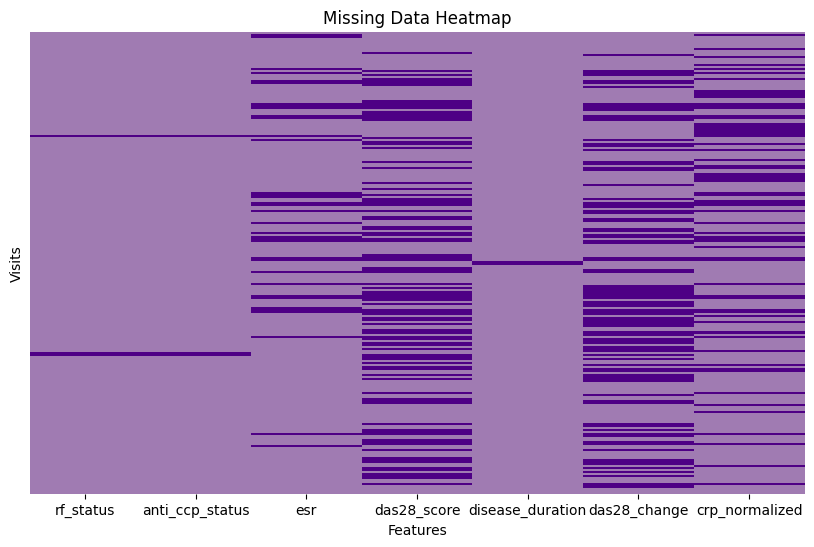

In [95]:
#Missingness Visualization
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#A07BB2FF", "#4e0085"])


#Heatmap of missing values
missing_cols = df_eda.columns[df_eda.isnull().any()]
plt.figure(figsize=(10, 6))
sns.heatmap(df_eda[missing_cols].isnull(), cbar=False, cmap=cmap, yticklabels=False)
plt.title('Missing Data Heatmap')
plt.xlabel('Features')
plt.ylabel('Visits')
plt.show()


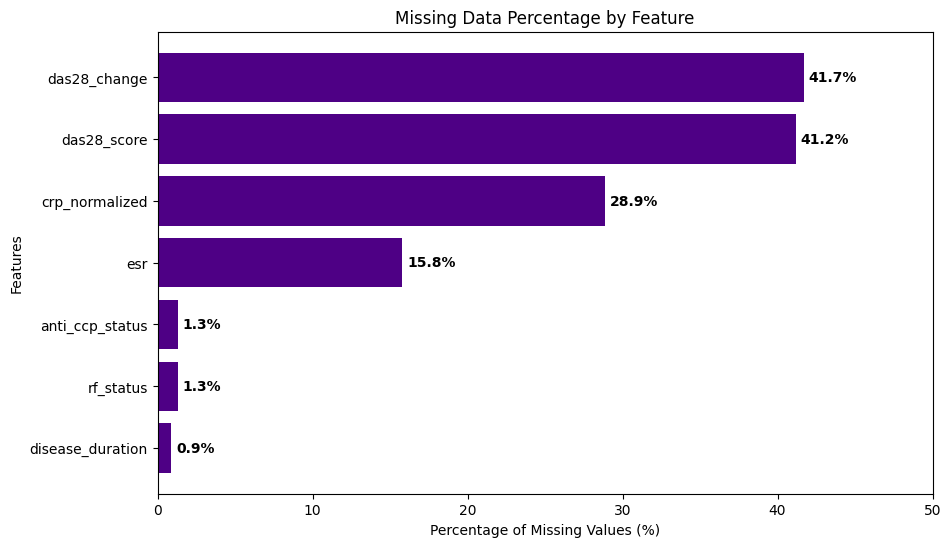

In [121]:
#Barplot of missing values
missing_plot = (missing_table[missing_table['missing_percentage'] > 0]
                .sort_values(by='missing_percentage', ascending=True))

plt.figure(figsize=(10, 6))
graph = plt.barh(missing_plot.index, missing_plot['missing_percentage'], color='#4e0085')

for p in graph:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    plt.text(
        width + 0.3,   
        y,
        f"{width:.1f}%",
        va="center",
        weight="bold"
    )

plt.title('Missing Data Percentage by Feature')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Features')
plt.xlim(0, 50)
plt.show()


In [156]:
crp_counts = pd.crosstab(df_eda['crp_missing'], df_eda['target_flare_next'], 
            rownames=['CRP missing'], colnames=['Flare next visit'])


crp_percent = pd.crosstab(df_eda["crp_missing"], df_eda["target_flare_next"], normalize="index", 
            rownames=["CRP missing"], colnames=["Flare next visit"]).round(2)

display(crp_counts)
display(crp_percent)

Flare next visit,0,1
CRP missing,,
0,96,66
1,42,24


Flare next visit,0,1
CRP missing,,
0,0.59,0.41
1,0.64,0.36


In [157]:
esr_counts = pd.crosstab(df_eda['esr_missing'], df_eda['target_flare_next'], 
            rownames=['ESR missing'], colnames=['Flare next visit'])


esr_percent = pd.crosstab(df_eda["esr_missing"], df_eda["target_flare_next"], normalize="index", 
            rownames=["ESR missing"], colnames=["Flare next visit"]).round(2)

display(esr_counts)
display(esr_percent)

Flare next visit,0,1
ESR missing,,
0,112,80
1,26,10


Flare next visit,0,1
ESR missing,,
0,0.58,0.42
1,0.72,0.28


In [158]:
df_eda['das28_missing'] = df_eda['das28_change'].isnull().astype(int)

das28_counts = pd.crosstab(df_eda['das28_missing'], df_eda['target_flare_next'], 
            rownames=['DAS28 Missing'], colnames=['Flare next visit'])


das28_percent = pd.crosstab(df_eda["das28_missing"], df_eda["target_flare_next"], normalize="index", 
            rownames=["DAS28 Missing"], colnames=["Flare next visit"]).round(2)

display(das28_counts)
display(das28_percent)

Flare next visit,0,1
DAS28 Missing,,
0,78,55
1,60,35


Flare next visit,0,1
DAS28 Missing,,
0,0.59,0.41
1,0.63,0.37


### Does feature missingness appear to affect the target variable?

<span style="color: green;">**CRP**</span>  
The proportion of next-visit flare was similar between visits with available and missing values.  
- When CRP is present (0) : 41%  
- When CRP is not present (1): 36%  
- Difference: 5%. 


This small difference suggests that CRP missingness is not strongly associated with the outcome and is unlikely to represent highly informative missingness.



<span style="color: cyan;">**ESR**</span>   
For ESR, visits with missing values showed a lower proportion of next-visit flare compared with visits where ESR was available.  
- When ESR is present (0) and available 80/192: 42%  
- When ESR is not present (1) and missing 10/36: 28%  
- Difference: 14%  

This more noticeable difference suggests that ESR missingness may carry some information and may not be completely random, although the number of visits with missing ESR was smaller.
  
<span style="color: purple;">**DAS28 score**</span>   
Because DAS28_score and DAS28_change are highly correlated, only das28_score missingness percentage was evaluated.  
The proportion of next-visit flare was similar between visits with available and missing values.  
- When DAS28 is present (0), and available 55/133: 41%  
- When DAS28 is not present (1) and available 35/95: 37%  
- Difference: 4%   

This small difference suggests that DAS28 score missingness is not strongly associated with the outcome.

In [ ]:
df_cleaned['treatment_decision'].value_counts(normalize=True, dropna=False) * 100


treatment_decision
NaN           30.701754
Stable        25.877193
Escalation    23.684211
Tapering      11.842105
Switch         7.894737
Name: proportion, dtype: float64

In [27]:
df_cleaned['days_since_last_flare_bin'] = pd.cut(
    df_cleaned['days_since_last_flare'],
    bins=[0, 30, 90, 180, 365, 1000]
)

pd.crosstab(
    df_cleaned['days_since_last_flare_bin'],
    df_cleaned['target_flare_next'],
    normalize='index'
)

df_cleaned['days_since_last_flare_bin'].value_counts(dropna=False)

days_since_last_flare_bin
NaN                157
(30.0, 90.0]        19
(180.0, 365.0]      19
(90.0, 180.0]       17
(365.0, 1000.0]     12
(0.0, 30.0]          4
Name: count, dtype: int64

In [15]:
pd.crosstab(df_cleaned['treatment_decision'], df_cleaned['target_flare_next'], normalize='index')


target_flare_next,0,1
treatment_decision,,
Escalation,0.518519,0.481481
Stable,0.627119,0.372881
Switch,0.722222,0.277778
Tapering,0.555556,0.444444


In [23]:
df_cleaned.loc[df_cleaned['treatment_decision'] == 'Switch', 'switch_reason'].value_counts(dropna=False)

switch_reason
Inefficacy       15
no_switch         2
Adverse event     1
Name: count, dtype: int64

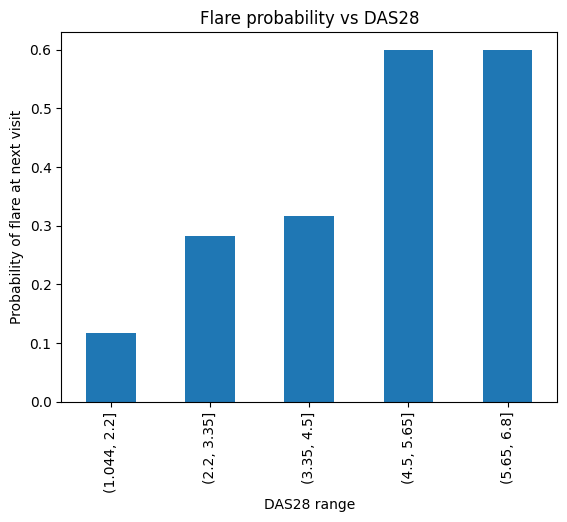

In [16]:
import matplotlib.pyplot as plt


df_cleaned['das28_bin'] = pd.cut(df_cleaned['das28_score'], bins=5)
flare_rate = df_cleaned.groupby('das28_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar')

plt.ylabel("Probability of flare at next visit")
plt.xlabel("DAS28 range")
plt.title("Flare probability vs DAS28")
plt.show()


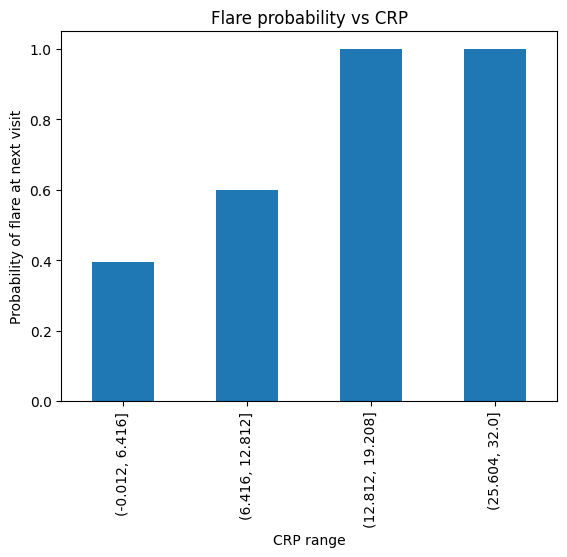

In [17]:
df_cleaned['crp_bin'] = pd.cut(df_cleaned['crp_normalized'], bins=5)
flare_rate = df_cleaned.groupby('crp_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar')

plt.ylabel("Probability of flare at next visit")
plt.xlabel("CRP range")
plt.title("Flare probability vs CRP")
plt.show()

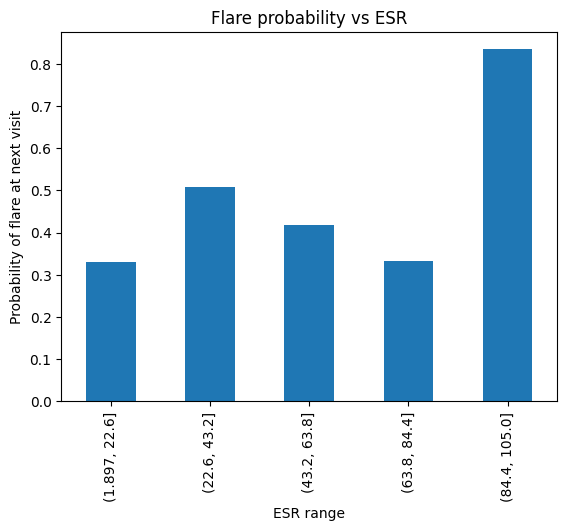

In [18]:
df_cleaned['esr_bin'] = pd.cut(df_cleaned['esr'], bins=5)
flare_rate = df_cleaned.groupby('esr_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar')

plt.ylabel("Probability of flare at next visit")
plt.xlabel("ESR range")
plt.title("Flare probability vs ESR")
plt.show()

In [19]:
pd.crosstab(
    df_cleaned['previous_flare'],
    df_cleaned['target_flare_next'],
    normalize='index'
)


target_flare_next,0,1
previous_flare,,
0,0.664286,0.335714
1,0.511364,0.488636


In [20]:

pd.crosstab(
    df_cleaned['flare_event'],
    df_cleaned['steroid_use'],
    normalize='index'
)


steroid_use,0,1
flare_event,,
0,0.669492,0.330508
1,0.490909,0.509091


In [21]:
df_cleaned['baseline_visit'] = (df_cleaned['visit_type'] == 'Baseline').astype(int)
pd.crosstab(
    df_cleaned['baseline_visit'],
    df_cleaned['target_flare_next'],
    normalize='index'
)

target_flare_next,0,1
baseline_visit,,
0,0.588608,0.411392
1,0.642857,0.357143


In [ ]:
# Boxplots of numeric predictors vs flare_event
numeric_cols = ['age_at_visit', 'das28_score', 'crp', 'esr', 'steroid_dose']
for col in numeric_cols:
    sns.boxplot(x='flare_event', y=col, data=df_cleaned)
    plt.title(f"{col} vs flare_event (raw)")
    plt.show()

# Bar plots for categorical predictors
categorical_cols = ['gender', 'rf_status', 'anti_ccp_status', 'csdmard_name', 'b_ts_dmard_name']
for col in categorical_cols:
    sns.countplot(x=col, hue='flare_event', data=df_cleaned)
    plt.title(f"{col} vs flare_event (raw)")
    plt.show()

In [11]:
unique_terms = set()

for row in df_cleaned['comorbidities']:
    if pd.notna(row):
        terms = row.lower().split(',')
        unique_terms.update([t.strip() for t in terms])

sorted(unique_terms)

['anxiety disorder',
 'ascending aortic aneurysm',
 'asthma',
 'atrial fibrillation',
 'benign prostatic hyperplasia',
 'beta thalassemia minor',
 'bilateral carpal tunnel syndrome',
 'brca_hx',
 'breast cancer',
 'carotid stenosis',
 'chronic kidney disease',
 'chronic obstructive pulmonary disease',
 'chronic venous insufficiency',
 'coronary artery disease',
 'cushing syndrome',
 'dementia',
 'depression',
 'diabetes mellitus',
 'dyslipidemia',
 'gastroesophageal reflux disease',
 'gout',
 'hashimoto',
 'heart attack',
 'heart failure',
 'hepatitis b',
 'hypertension',
 'hypothyroidism',
 'kidney cancer',
 'lumbar spondylosis',
 'mesenteric lipodystrophy',
 'monoclonal gammopathy of undetermined significance',
 'nephrolithiasis',
 'none',
 'operated meningioma',
 'osteoarthritis',
 'osteopenia',
 'osteoporosis',
 'parkinsonism',
 'parotid cancer',
 'paroxysmal supraventricular tachycardia',
 'pericarditis',
 'postherpetic neuralgia',
 'prostatitis',
 'pulmonary fibrosis',
 'resolved

In [ ]:
def split_comorbidities(text):
    if not text:
        return []
    return [x.strip() for x in text.split(",") if x.strip()]

df_patient = df_cleaned[['patient_id', 'comorbidities_clean']].drop_duplicates()

# flatten all comorbidities into one list
all_comorbidities = []
for txt in df_patient["comorbidities_clean"]:
    all_comorbidities.extend(split_comorbidities(txt))

# frequency table
freq = pd.DataFrame(Counter(all_comorbidities).items(), columns=["comorbidity", "count"])
freq = freq.sort_values("count", ascending=False).reset_index(drop=True)

print(freq)

                  comorbidity  count
0                dyslipidemia     27
1                hypertension     14
2                osteoporosis     11
3              hypothyroidism     10
4                         cad      7
5                        gerd      6
6                          af      5
7                tuberculosis      4
8                          oa      4
9           diabetes mellitus      4
10                 depression      3
11                       copd      3
12                hepatitis b      3
13                    brca_hx      2
14                         hf      2
15       resolved hepatitis b      2
16                   hasimoto      2
17           anxiety disorder      2
18                        btm      2
19                        tia      1
20    χειρουργηθεν μηνιγγιωμα      1
21              kidney cancer      1
22                thalassemia      1
23           cushing syndrome      1
24            nephrolithiasis      1
25                prostatitis      1
2